## Transformer Model Chatbot

In [ ]:
!sudo apt-get install g++ openjdk-8-jdk
!sudo apt-get install curl

!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)

!pip install konlpy

In [ ]:
!pip install sentencepiece nltk

### 라이브러리, 데이터 준비하기 

In [1]:
import numpy as np
import pandas as pd
import torch
import sentencepiece as spm
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction
from torch.utils.data import DataLoader, Dataset

import re
import os
import random
import math

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print(torch.__version__)

2.7.1+cu118


In [2]:
import pandas as pd

# 데이터 로드
df = pd.read_csv('/home/jovyan/data/ChatbotData.csv')

# 상위 5개 데이터 확인
print(df.head())

# 데이터 정보 확인
print(df.info())

# 데이터 통계 및 결측치 확인
print(df.isnull().sum())

                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11823 entries, 0 to 11822
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Q       11823 non-null  object
 1   A       11823 non-null  object
 2   label   11823 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 277.2+ KB
None
Q        0
A        0
label    0
dtype: int64


일상다반사 0, 이별(부정)1, 사랑(긍정)2로 레이블링

#### 데이터 전처리

#### 중복 데이터 제거

In [3]:
print(df['Q'].nunique())
print(df['A'].nunique())

11662
7779


In [4]:
# inplace=True 를 설정하면 DataFrame 타입 값을 return 하지 않고 data 내부를 직접적으로 바꿉니다
df.drop_duplicates(subset = ['Q'], inplace=True)
print('전체 샘플수 :', (len(df)))

전체 샘플수 : 11662


In [5]:
print(df.isnull().sum())

Q        0
A        0
label    0
dtype: int64


In [6]:
def preprocess_sentence(sentence):
    # 1. 양쪽 공백 제거
    sentence = sentence.strip()

    # 2. 단어와 구두점(?.!,) 사이의 거리를 만듭니다.
    # 한글 뒤에 바로 붙은 마침표 등을 분리합니다.
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)

    # 3. 한글(가-힣), 자음(ㄱ-ㅎ), 모음(ㅏ-ㅣ), 알파벳, 숫자, 그리고 주요 구두점을 제외한 
    # 모든 문자를 공백 ' '으로 대체합니다.
    # (특수기호나 이모지 등을 제거하는 역할)
    sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣa-zA-Z0-9?.!, ]+", " ", sentence)
    
    # 4. 다시 한번 양쪽 공백 제거
    sentence = sentence.strip()
    return sentence

In [7]:
# 질문(Q) 전처리
questions = []
for sentence in df['Q']:
    questions.append(preprocess_sentence(sentence))

# 답변(A) 전처리
answers = []
for sentence in df['A']:
    answers.append(preprocess_sentence(sentence))

# 결과 출력
print("질문 전처리 후 결과: ", questions[:5])
print("답변 전처리 후 결과: ", answers[:5])

질문 전처리 후 결과:  ['12시 땡 !', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다', '3박4일 정도 놀러가고 싶다', 'PPL 심하네']
답변 전처리 후 결과:  ['하루가 또 가네요 .', '위로해 드립니다 .', '여행은 언제나 좋죠 .', '여행은 언제나 좋죠 .', '눈살이 찌푸려지죠 .']


questions의 최소 길이 : 1
questions의 최대 길이 : 16
questions의 평균 길이 : 3.948550848910993
answers의 최소 길이 : 1
answers의 최대 길이 : 16
answers의 평균 길이 : 3.948550848910993


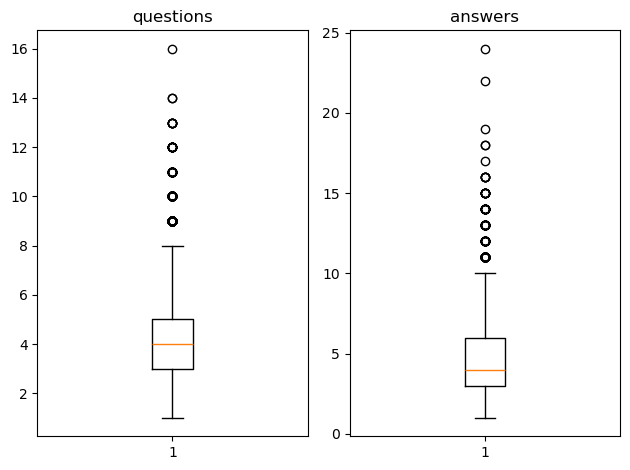

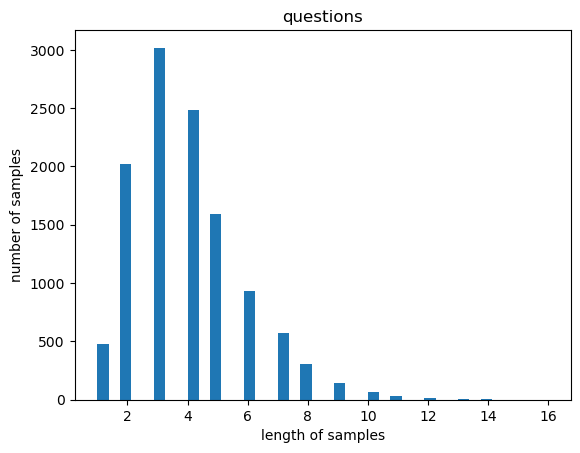

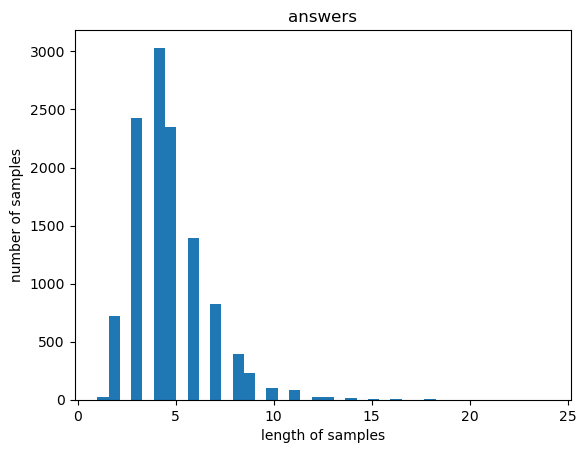

In [8]:
# 길이 분포 출력
import matplotlib.pyplot as plt

q_len = [len(s.split()) for s in questions]
a_len = [len(s.split()) for s in answers]

print('questions의 최소 길이 : {}'.format(np.min(q_len)))
print('questions의 최대 길이 : {}'.format(np.max(q_len)))
print('questions의 평균 길이 : {}'.format(np.mean(q_len)))
print('answers의 최소 길이 : {}'.format(np.min(a_len)))
print('answers의 최대 길이 : {}'.format(np.max(q_len)))
print('answers의 평균 길이 : {}'.format(np.mean(q_len)))

plt.subplot(1,2,1)
plt.boxplot(q_len)
plt.title('questions')
plt.subplot(1,2,2)
plt.boxplot(a_len)
plt.title('answers')
plt.tight_layout()
plt.show()

plt.title('questions')
plt.hist(q_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

plt.title('answers')
plt.hist(a_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

### data augmentation

#### Lexical Substitution 구현

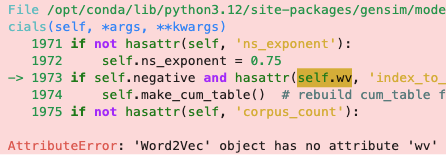

'Word2Vec' object has no attribute 'wv' 에러 발생

참고 : https://recipesds.tistory.com/entry/word2vec을-gensim-4x-용으로-업그레이드-하는-법

''' 현재 인터넷에 공개되어 있는 kyubyong/word2vec 모델은 gensim 3x에서 개발되었고, binary format이 틀림
지금 현재 최신 gensim은 4.4이고, 이 모델 binary를 읽을 수 없음
왠만한 제안들이 python 3.8이하에 gensim 3x 를 사용하라고 제안하지만, 그러고 싶지 않음
그래서 객체에 그대로 불러드리는 것이 아니라, 순수 binary만 읽어들여서 그것을 객체에 넣은 후 다시 저장하는 방법을
구현함. '''

In [ ]:
!pip install gensim
!pip install gdown

In [9]:
from io import BytesIO
import gensim
from gensim.models import KeyedVectors
import zipfile
import urllib.request
import os
import numpy as np
import pickle
import torch

In [10]:
wordvec_path = './ko.bin'
converted_model_path = './ko_w2v_format.bin'

# 2. pickle 파일을 바이트 스트림으로 로드하고, 내부 데이터만 추출
with open(wordvec_path, 'rb') as f:
    file_bytes = BytesIO(f.read())
    unpickler = pickle.Unpickler(file_bytes, encoding='latin1')
    old_model_data = unpickler.load()

# 3. old_model_data에서 직접 벡터와 단어 목록 추출
word_vectors = old_model_data.syn0
word_key_to_index = {word: index for index, word in enumerate(old_model_data.index2word)}

# 4. 새로운 KeyedVectors 객체로 재구성
new_kv = KeyedVectors(vector_size=word_vectors.shape[1])
new_kv.add_vectors(list(word_key_to_index.keys()), word_vectors)

# 5. 표준 word2vec 포맷으로 저장
new_kv.save_word2vec_format(converted_model_path, binary=True)
print("모델 변환 완료. 새로운 파일: ko_w2v_format.bin")

# 6. 변환된 모델을 KeyedVectors로 로드하여 사용
loaded_model = KeyedVectors.load_word2vec_format(converted_model_path, binary=True)
print("최종 모델 로드 완료.")

# 모델 사용
print(loaded_model.most_similar('바나나'))

모델 변환 완료. 새로운 파일: ko_w2v_format.bin
최종 모델 로드 완료.
[('코코넛', 0.8097118735313416), ('시금치', 0.7701147198677063), ('레몬', 0.76884925365448), ('땅콩', 0.7684734463691711), ('파인애플', 0.7639914751052856), ('녹차', 0.7631460428237915), ('딸기', 0.7617197036743164), ('바닐라', 0.7497864961624146), ('파슬리', 0.7447543740272522), ('코코아', 0.7408245205879211)]


In [11]:
# 2. Lexical Substitution 함수 (제공된 코드 그대로)
import random

def lexical_sub(sentence, new_kv):
    tokens = sentence.split()
    valid_tokens = [tok for tok in tokens if tok in new_kv]

    if not valid_tokens:
        return sentence

    selected_tok = random.choice(valid_tokens)
    similar_word = new_kv.most_similar(selected_tok)[0][0]
    new_sentence = " ".join([similar_word if tok == selected_tok else tok for tok in tokens])

    return new_sentence

In [12]:
# 3. Q와 A 각각에 대해 Augmentation 수행
aug_questions = []
for sentence in tqdm(questions):
    aug_questions.append(lexical_sub(sentence, new_kv))

aug_answers = []
for sentence in tqdm(answers):
    aug_answers.append(lexical_sub(sentence, new_kv))

print("원본 Q 예시:", questions[0])
print("증강 Q 예시:", aug_questions[0])
print("원본 A 예시:", answers[0])
print("증강 A 예시:", aug_answers[0])


  0%|          | 0/11662 [00:00<?, ?it/s]

  0%|          | 0/11662 [00:00<?, ?it/s]

원본 Q 예시: 12시 땡 !
증강 Q 예시: 12시 땡 캐치
원본 A 예시: 하루가 또 가네요 .
증강 A 예시: 하루가 각기 가네요 .


In [14]:
# 4. 데이터 3배 확장 (원본 + 증강Q-원본A + 원본Q-증강A)
#    - 원본 Q + 원본 A          (원본)
#    - 증강 Q + 원본 A          (Q만 augmentation)
#    - 원본 Q + 증강 A          (A만 augmentation)

all_questions = questions + aug_questions + questions
all_answers   = answers   + answers       + aug_answers

print(f"원본 데이터 수: {len(questions)}")
print(f"증강 후 전체 데이터 수: {len(all_questions)}")  # 약 3배

원본 데이터 수: 11662
증강 후 전체 데이터 수: 34986


#### 토큰화

In [ ]:
!pip install konlpy 
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git 
%cd Mecab-ko-for-Google-Colab/ 
!bash install_mecab-ko_on_colab_light_220429.sh

In [15]:
from konlpy.tag import Mecab

mecab = Mecab()

def tokenize_korean(text):
    tokens = mecab.morphs(str(text))
    return ' '.join(tokens)

with open("q_corpus.txt", "w", encoding="utf-8") as f:
    for text in all_questions:
        tokenized = tokenize_korean(text)
        f.write(tokenized + "\n")

with open("a_corpus.txt", "w", encoding="utf-8") as f:
    for text in all_answers:
        tokenized = tokenize_korean(text)
        f.write(tokenized + "\n")

vocab_size = 2000
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

spm.SentencePieceTrainer.train(
    input="q_corpus.txt",
    model_prefix="encoder_spm",
    vocab_size=vocab_size,
    pad_id=pad_id,
    bos_id=bos_id,
    eos_id=eos_id,
    unk_id=unk_id
)

spm.SentencePieceTrainer.train(
    input="a_corpus.txt",
    model_prefix="decoder_spm",
    vocab_size=vocab_size,
    pad_id=pad_id,
    bos_id=bos_id,
    eos_id=eos_id,
    unk_id=unk_id
)

encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("encoder_spm.model")

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("decoder_spm.model")

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: q_corpus.txt
  input_format: 
  model_prefix: encoder_spm
  model_type: UNIGRAM
  vocab_size: 2000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  dif

True

RuntimeError: Internal: src/trainer_interface.cc(664) [(trainer_spec_.vocab_size()) == (model_proto->pieces_size())] Vocabulary size too high (3000). Please set it to a value <= 2076.


In [16]:
q_sample = questions[0]
a_sample = answers[0]
print(q_sample)
print(a_sample)

12시 땡 !
하루가 또 가네요 .


In [17]:
def make_corpus(sentences, tokenizer):
    corpus = []
    for sentence in tqdm(sentences):
        tokens = tokenizer.encode_as_ids(sentence)
        corpus.append(tokens)
    return corpus

print('슝=3')

슝=3


In [18]:
q_corpus = make_corpus(all_questions, encoder_tokenizer)
a_corpus = make_corpus(all_answers, decoder_tokenizer)

  0%|          | 0/34986 [00:00<?, ?it/s]

  0%|          | 0/34986 [00:00<?, ?it/s]

In [19]:
print(all_questions[0])
print(q_corpus[0])
print('\n')
print(all_answers[0])
print(a_corpus[0])

12시 땡 !
[4, 1976, 1370, 121, 4, 1885, 4, 1969]


하루가 또 가네요 .
[455, 71, 490, 18, 797, 10, 4]


#### Target 데이터 ans_corpus에 start 토큰과 end 토큰 추가

In [20]:
class ChatbotDataset(Dataset):
    def __init__(self, q_corpus, a_corpus, max_len):
        self.q_corpus = q_corpus
        self.a_corpus = a_corpus
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.q_corpus)

    def __getitem__(self, idx):
        src_ids = list(self.q_corpus[idx])
        trg_ids = list(self.a_corpus[idx])

        src_ids = src_ids[:self.max_len]

        # Decoder의 입력에는 START_TOKEN과 END_TOKEN을 추가해줍니다. 단, 최대 길이 제한을 적용시킵니다.
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 길이가 짧은 경우 PAD_TOKEN을 추가해줍니다.
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

In [21]:
MAX_LEN = 30

def pad_sequences_custom(sequences, max_len=50, pad_value=0):
    """
    sequences: list of list (각 문장별 토큰 ID 리스트)
    max_len: 고정할 최대 시퀀스 길이
    pad_value: 패딩에 사용할 값 (일반적으로 0)
    """
    padded_sequences = []

    for seq in sequences:
        # 초과 길이는 자르고
        if len(seq) > max_len:
            seq = seq[:max_len]
        # 부족한 길이는 pad_value로 채우기
        else:
            seq = seq + [pad_value] * (max_len - len(seq))

        padded_sequences.append(seq)

    # 최종적으로 torch.Tensor로 변환 (shape: [batch_size, max_len])
    return torch.tensor(padded_sequences, dtype=torch.long)

enc_ndarray = pad_sequences_custom(q_corpus, max_len=MAX_LEN, pad_value=0)
dec_ndarray = pad_sequences_custom(a_corpus, max_len=MAX_LEN, pad_value=0)

print(enc_ndarray.shape)  # 예) [batch_size, 50]
print(dec_ndarray.shape)  # 예) [batch_size, 50]
print("슝=3")

torch.Size([34986, 30])
torch.Size([34986, 30])
슝=3


In [22]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_dataset = TensorDataset(enc_ndarray, dec_ndarray)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

print("슝=3")

슝=3


### Transformer 구현하기 

#### Positional Encoding

In [23]:
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table
print("슝=3")

슝=3


#### 마스크 생성

In [24]:
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """
    seq: shape [batch_size, seq_len]의 입력 (토큰 ID 텐서)
    반환: shape [batch_size, 1, 1, seq_len]의 패딩 마스크
         (seq == 0)인 위치가 1, 나머지는 0
    """
    # (seq == 0)은 불리언 텐서를 반환 -> float()로 형변환 -> (1.0 or 0.0)
    # 차원 확장: [batch_size, seq_len] → [batch_size, 1, 1, seq_len]
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """
    size: 문장(시퀀스) 길이
    반환: shape [size, size],
         i < j (대각선 위)에 해당하는 위치가 1, 아닌 곳은 0
         (미래 토큰을 가리기 위한 마스크)
    """
    # triu(diagonal=1)은 주대각선 위가 1, 아래가 0인 텐서를 만들어 줌
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    """
    src, tgt: shape [batch_size, seq_len]
    3가지 마스크를 반환:
      - enc_mask: 인코더 입력용 패딩 마스크
      - dec_enc_mask: 디코더-인코더 어텐션용 패딩 마스크
      - dec_mask: 디코더 자기어텐션용 마스크(룩어헤드 + 패딩)

    각각의 shape:
      - enc_mask, dec_enc_mask: [batch_size, 1, 1, src_seq_len]
      - dec_mask: [batch_size, 1, tgt_seq_len, tgt_seq_len]
    """
    # 1) 인코더 입력용 패딩 마스크
    enc_mask = generate_padding_mask(src)
    # 2) 디코더에서 인코더 값을 볼 때 사용하는 마스크 (src 마스크 재사용)
    dec_enc_mask = generate_padding_mask(src)

    # 3) 디코더 자기어텐션 마스크 (미래 토큰 방지 룩어헤드 + tgt 자체 패딩 마스크)
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])  # [tgt_seq_len, tgt_seq_len]
    dec_tgt_padding_mask = generate_padding_mask(tgt)           # [batch_size, 1, 1, tgt_seq_len]

    # 룩어헤드 마스크를 (batch 차원과 head 차원을 가상으로) 확장
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)  # [1, 1, seq_len, seq_len]

    # 패딩 + 룩어헤드 마스크 병합
    # 브로드캐스팅에 의해 shape [batch_size, 1, tgt_seq_len, tgt_seq_len]이 됨

    dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
    dec_lookahead_mask = dec_lookahead_mask.to(device)

    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask

print("슝=3")

슝=3


#### Multi-head Attention

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model을 num_heads로 나눈 만큼이 각 head가 담당할 차원 수
        self.depth = d_model // num_heads

        # Query, Key, Value를 구하는 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종적으로 head들의 출력을 결합해주는 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V:  [batch_size, num_heads, seq_len, depth]
        mask:     [batch_size, 1, seq_len, seq_len] 혹은
                  [batch_size, num_heads, seq_len, seq_len]
                  (어텐션에서 제외할 위치=1, 사용할 위치=0)
        """
        # d_k = depth
        d_k = Q.size(-1)  # K.shape[-1]도 동일
        # Q와 K의 전치 곱: (batch_size, num_heads, seq_len, seq_len)
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # 스케일링
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크가 있는 경우 -1e9(매우 작은 수)를 더하여 softmax 후 확률이 0에 가깝도록 처리
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
        out = torch.matmul(attentions, V)         # (batch_size, num_heads, seq_len, depth)

        return out, attentions

    def split_heads(self, x):
        """
        x: [batch_size, seq_len, d_model]
        반환: [batch_size, num_heads, seq_len, depth]
        """
        bsz, seq_len, _ = x.size()
        # d_model -> (num_heads * depth)이므로 view로 재배치
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        # (batch_size, seq_len, num_heads, depth) -> (batch_size, num_heads, seq_len, depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """
        x: [batch_size, num_heads, seq_len, depth]
        반환: [batch_size, seq_len, d_model]
        """
        bsz, num_heads, seq_len, depth = x.size()
        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch_size, seq_len, d_model]
        mask:    [batch_size, 1, seq_len, seq_len] 혹은
                 [batch_size, num_heads, seq_len, seq_len]
        """
        # W_q, W_k, W_v는 각각 (d_model -> d_model) 선형 변환
        WQ = self.W_q(Q)  # [batch_size, seq_len, d_model]
        WK = self.W_k(K)  # [batch_size, seq_len, d_model]
        WV = self.W_v(V)  # [batch_size, seq_len, d_model]

        # 멀티헤드 분할
        WQ_splits = self.split_heads(WQ)  # [batch_size, num_heads, seq_len, depth]
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # Scaled dot-product attention
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # head 결과 결합 후 최종 선형
        out = self.combine_heads(out)  # [batch_size, seq_len, d_model]
        out = self.linear(out)         # [batch_size, seq_len, d_model]

        return out, attention_weights

print("슝=3")

슝=3


#### Position-wise Feed Forward Network

In [26]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))  # 첫 번째 Dense + ReLU
        out = self.fc2(out)          # 두 번째 Dense
        return out

print("슝=3")

슝=3


#### Encoder layer

In [27]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # nn.LayerNorm은 마지막 차원(d_model)을 기준으로 정규화
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Multi-Head Attention 단계
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual  # residual connection

        # Position-Wise Feed Forward 단계
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual  # residual connection

        return out, enc_attn

print("슝=3")

슝=3


#### Decoder Layer

In [28]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # Masked Multi-Head Attention
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # Encoder-Decoder Multi-Head Attention (주의: Q, K, V 순서)
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn

print("슝=3")

슝=3


#### Encoder

In [29]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.do = nn.Dropout(dropout)  # 필요 시 입력에 dropout 적용 가능

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns

# 사용 예시: Encoder 인스턴스 생성 후 forward 호출
# encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
# out, enc_attns = encoder(x, mask)
print("슝=3")

슝=3


#### Decoder

In [30]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = self.dec_layers[i](out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns

print("슝=3")

슝=3


#### Transfomer 전체 모델 조립

In [31]:
import math

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        # d_model은 스케일링에 사용되므로 float으로 저장
        self.d_model = float(d_model)

        # Embedding 레이어: shared_emb True면 동일한 임베딩을 사용합니다.
        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # Positional encoding (넘파이 버전 결과를 torch.Tensor로 변환)
        pos_encoding_np = positional_encoding(pos_len, d_model)
        # 파라미터로 등록하지 않고 고정값이므로 buffer로 등록합니다.
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            # fc 레이어와 디코더 임베딩의 weight를 공유합니다.
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        """
        emb: 임베딩 레이어
        x: [batch_size, seq_len] (토큰 인덱스)
        """
        seq_len = x.size(1)
        out = emb(x)  # [batch_size, seq_len, d_model]
        if self.shared_fc:
            out = out * math.sqrt(self.d_model)
        # pos_encoding: [pos_len, d_model] → [1, pos_len, d_model] 후 슬라이싱
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        """
        enc_in: [batch_size, src_seq_len]
        dec_in: [batch_size, tgt_seq_len]
        enc_mask, dec_enc_mask, dec_mask: 마스킹 텐서들
        """
        # Embedding 및 positional encoding 적용
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # Encoder와 Decoder 통과
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


#### 모델 인스턴스 생성

In [49]:
# 주어진 하이퍼파라미터로 Transformer 인스턴스 생성
transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048, 
    src_vocab_size=vocab_size,
    tgt_vocab_size=vocab_size,
    pos_len= MAX_LEN,
    dropout=0.3,
    shared_fc=True,
    shared_emb=True)

transformer = transformer.to(device)

d_model = 512

print("슝=3")

슝=3


1. n_layers=2
   - 트랜스포머의 인코더와 디코더 각각의 층 수
   - 여기서는 2개의 층으로 구성

2. d_model=512
   - 모델의 기본 임베딩 차원 크기
   - 모든 서브레이어의 출력 차원이며, 모델 전반에 걸쳐 유지되는 차원

3. n_heads=8
   - 멀티헤드 어텐션에서 사용할 헤드(head)의 개수
   - 어텐션을 8개의 다른 관점에서 병렬적으로 수행

4. d_ff=2048
   - Position-wise Feed-Forward Network의 은닉층 크기
   - 피드포워드 네트워크의 중간 차원

5. src_vocab_size=VOCAB_SIZE
   - 입력(소스) 언어의 어휘 크기
   - 인코더의 임베딩 레이어에서 사용

6. tgt_vocab_size=VOCAB_SIZE
   - 출력(타겟) 언어의 어휘 크기
   - 디코더의 임베딩 레이어에서 사용

7. pos_len=200
   - 포지셔널 인코딩의 최대 시퀀스 길이
   - 처리할 수 있는 입력 문장의 최대 길이

8. dropout=0.3
   - 드롭아웃 비율 (30%)
   - 과적합 방지를 위해 사용

9. shared_fc=True
   - 디코더의 출력층과 임베딩 가중치 공유 여부
   - True면 출력층과 임베딩 레이어의 가중치를 공유

10. shared_emb=True
    - 인코더와 디코더의 임베딩 레이어 공유 여부
    - True면 인코더와 디코더가 동일한 임베딩 사용

#### Learning Rate Scheduler

In [50]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=60): # 4000
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # step을 float으로 변환하여 지수 연산이 제대로 수행되도록 함
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)

print("슝=3")

슝=3


#### Learing Rate & Optimizer

In [51]:
# Learning Rate 인스턴스 선언
learning_rate = LearningRateScheduler(d_model)

# 초기 lr은 스텝 1에 해당하는 값으로 설정합니다.
optimizer = torch.optim.Adam(transformer.parameters(),
                             lr=learning_rate(1),
                             betas=(0.9, 0.98),
                             eps=1e-9)

print("슝=3")

슝=3


#### Loss Function 정의

In [52]:
def loss_function(real, pred):
    """
    real: [batch_size, seq_len] (정답 토큰 인덱스)
    pred: [batch_size, seq_len, num_classes] (모델의 raw logits)
    """

    real = real.to(device)
    pred = pred.to(device)

    # 예측 값을 (N, C) 형태로 flatten하고, 정답도 flatten하여 개별 손실 값을 구함
    loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)), real.contiguous().view(-1), reduction='none')
    # 다시 (batch_size, seq_len)로 reshape
    loss_ = loss_.view(real.size())

    # real이 0이 아닌 위치에 대한 마스크 생성 (0이면 패딩 토큰)
    mask = (real != 0).float()
    loss_ = loss_ * mask

    # 전체 손실 합을 마스크 합으로 나누어 평균 손실 계산
    return loss_.sum() / mask.sum()

print("슝=3")

슝=3


#### Time Step 정의

In [53]:
def train_step(src, tgt, model, optimizer):
    model.train()  # 모델을 training 모드로 전환
    optimizer.zero_grad()

    # tgt의 오른쪽 시프트: decoder input과 gold target 분리
    tgt_in = tgt[:, :-1]  # Decoder의 입력
    gold = tgt[:, 1:]     # Decoder의 정답(target)

    # 마스크 생성 (generate_masks는 PyTorch용으로 변환된 함수여야 합니다)
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)

    src = src.to(device)
    tgt_in = tgt_in.to(device)
    enc_mask = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)
    dec_mask = dec_mask.to(device)

    # 모델 forward pass
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)

    # loss 계산
    loss = loss_function(gold, predictions)

    # 역전파 수행 및 파라미터 업데이트
    loss.backward()
    optimizer.step()

    return loss, enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


#### 모델 훈련

In [54]:
%%time

EPOCHS = 10
history = []

for epoch in range(EPOCHS):
    total_loss = 0.0
    dataset_count = len(train_dataloader)  # train_loader는 PyTorch DataLoader입니다.
    tqdm_bar = tqdm(total=dataset_count)

    for batch, (src, tgt) in enumerate(train_dataloader):
        # train_step 함수는 (loss, enc_attns, dec_attns, dec_enc_attns)를 반환합니다.
        loss, enc_attns, dec_attns, dec_enc_attns = train_step(src, tgt, transformer, optimizer)

        total_loss += loss.item()  # PyTorch에서는 loss.numpy() 대신 loss.item() 사용
        tqdm_bar.set_postfix({"Batch Loss": f"{loss.item():.4f}"})
        tqdm_bar.update(1)

    tqdm_bar.close()

    epoch_loss = total_loss / dataset_count
    history.append(epoch_loss)
    
    print(f"Epoch {epoch+1}, Loss: {total_loss / dataset_count:.4f}")

  0%|          | 0/547 [00:00<?, ?it/s]

Epoch 1, Loss: 7002.5828


  0%|          | 0/547 [00:00<?, ?it/s]

Epoch 2, Loss: 3716.0336


  0%|          | 0/547 [00:00<?, ?it/s]

...

Epoch 8, Loss: 1685.6465


  0%|          | 0/547 [00:00<?, ?it/s]

Epoch 9, Loss: 1540.3129


  0%|          | 0/547 [00:00<?, ?it/s]

Epoch 10, Loss: 1411.9544
CPU times: user 6min 51s, sys: 2.65 s, total: 6min 54s
Wall time: 5min 31s


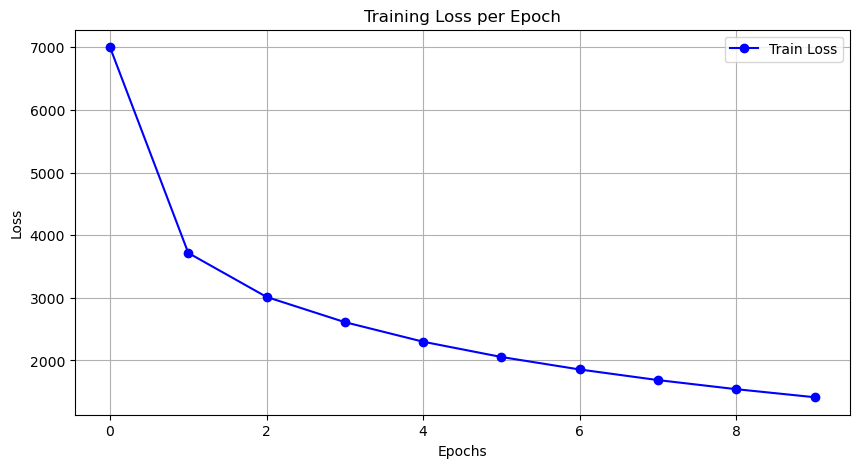

In [55]:
import matplotlib.pyplot as plt

# 기존 train_losses 대신 학습 루프에서 쌓인 history를 사용합니다.
plt.figure(figsize=(10, 5))
plt.plot(history, label='Train Loss', color='blue', marker='o')

plt.title('Training Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Epoch 100 일 때
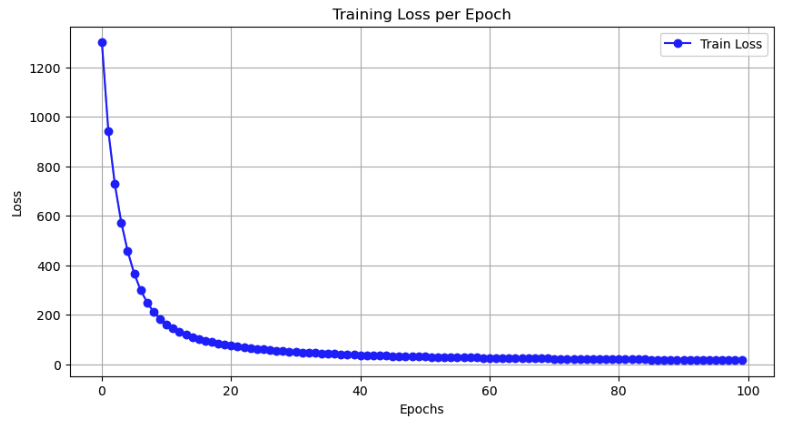

### 번역 성능 측정

In [56]:
import torch
import matplotlib.pyplot as plt

def evaluate(sentence, transformer, encoder_tokenizer, decoder_tokenizer, max_len=30):
    transformer.eval()

    sentence = preprocess_sentence(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))
    
    # 1. Transformer 입력 구조 (batch_size, seq_len)에 맞추기 위해 unsqueeze(0) 사용
    src_tensor = torch.tensor(src_ids).unsqueeze(0).to(device)

    # 디코더 입력 초기화 (BOS=1, EOS=2, PAD=0)
    bos_id = 1
    eos_id = 2
    pad_id = 0
    tgt_ids = [bos_id]

    with torch.no_grad():
        for i in range(max_len):
            # 2. 현재까지의 tgt_ids를 텐서로 변환 (batch_size, seq_len)
            tgt_tensor = torch.tensor(tgt_ids).unsqueeze(0).to(device)
            
            # 3. Transformer를 위한 마스크 생성 및 디바이스 이동
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src_tensor, tgt_tensor)
            enc_mask = enc_mask.to(device)
            dec_enc_mask = dec_enc_mask.to(device)
            dec_mask = dec_mask.to(device)

            # 4. 모델 추론 (마스크 포함하여 5개의 인자 전달)
            outputs, enc_attns, dec_attns, dec_enc_attns = transformer(src_tensor, tgt_tensor, enc_mask, dec_enc_mask, dec_mask)

            # outputs 차원: (batch_size, seq_len, vocab_size)
            # 현재 스텝에서 가장 확률이 높은 다음 토큰 예측
            next_token = outputs.argmax(2)[0, -1].item()
            tgt_ids.append(next_token)

            if next_token == eos_id:
                break

    # 정수 토큰을 문자열 단어로 변환 (특수 토큰 제외)
    result = [decoder_tokenizer.decode([token]) for token in tgt_ids if token not in [bos_id, eos_id, pad_id]]

    # 5. 어텐션 맵 반환 
    # dec_enc_attns는 여러 레이어의 어텐션을 담은 리스트입니다. 
    # 마지막 레이어(-1), 첫 번째 배치(0)에서 여러 헤드의 평균(mean)을 구해 시각화에 사용합니다.
    attention = dec_enc_attns[-1][0].mean(dim=0).cpu().numpy()

    return result, sentence, attention

def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()

def translate(sentence, transformer, encoder_tokenizer, decoder_tokenizer, max_len=30):
    result, sentence, attention = evaluate(sentence, transformer, encoder_tokenizer, decoder_tokenizer, max_len)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # 에러 방지를 위해 실제 데이터 크기에 맞춰 어텐션 슬라이싱 범위를 안전하게 조정
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result)


Input: 지루하다 , 놀러가고 싶어 .
Predicted translation: ['.', '히', '하', '는', '게', '좋', '은', '사', '람', '이', '지', '도', '', '있', '어요', '.', '청', '청', '청', '청', '청', '청', '청', '청', '청', '청', '청', '청', '청', '청']


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47336 (\N{HANGUL SYLLABLE RU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45440 (\N{HANGUL SYLLABLE NOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/cond

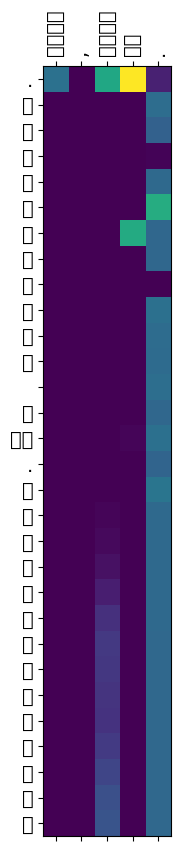

In [57]:
translate("지루하다, 놀러가고 싶어.", transformer, encoder_tokenizer, decoder_tokenizer, max_len=30)

#### 회고

Input: 지루하다 , 놀러가고 싶어 .

Predicted translation: ['.', '히', '하', '는', '게', '좋', '은', '사', '람', '이', '지', '도', '', '있', '어요', '.', '청', '청', '청', '청', '청', '청', '청', '청', '청', '청', '청', '청', '청', '청']

일단 데이터 전처리부터 augmentation, 모델학습까지는 진행했지만 답변 생성에 실패했고, 성능 측정은 하지 못했다.

위의 출력물과 같은 이유가 왜 나타났을까..

1. 데이터 부족으로 인한 모델의 학습 부족 (Underfitting)
문맥과 언어 규칙을 제대로 학습하려면 많은 양의 데이터가 필요하지만, 그럼에도 불구하고 조금이라도 과적합을 피할 수 있었을텐데 아직은 그 이유를 찾기 어렵다. 

2. 지나치게 작은 단어장(Vocab) 크기와 토큰화의 한계
단어장 크기를 2,000개 수준으로 너무 작게 설정해서 그럴 수도 있을 것 같다. 의미 있는 형태소나 단어 단위로 쪼개지지 못하고 글자 단위로 쪼개지다 보니, 모델이 예측해야 할 시퀀스 길이가 쓸데없이 길어졌다. 이로 인해 모델이 문맥을 잃어버리고 엉뚱한 예측을 반복하게 되었다. 

3. 종료 토큰(EOS) 학습 실패와 무한 생성 문제 (+ Gemini 원인 분석)
문장이 완성되면 모델이 [EOS] 토큰을 뱉고 문장 생성을 스스로 멈춰야 하는데(if next_token == eos_id: break), 언제 문장을 끝내야 하는지 전혀 배우지 못했다. 그 결과 설정해 둔 최대 길이인 30번째 스텝을 다 채울 때까지 의미 없는 글자들을 억지로 꾸역꾸역 채워 넣는 현상이 발생했다.